In [1]:
from train_dynamic_individual_cichy import *

import inspect
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import shutil
from PIL import Image
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torch
from torch.nn import DataParallel
from sklearn.metrics.pairwise import cosine_similarity
import h5py
import warnings

from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings("ignore", category=UserWarning)

p_id = 0
p_id_2 = 1
p_id_3 = 2
p_id_4 = 3

model_folder = './models/test_models/cichy_individual_transfer/'

model_path = f'{model_folder}/cliphba_dynamic_individual_cichy_p{p_id+1}.pth'

classnames = classnames66
smoothen_window = 5
backbone = "ViT-L/14"
pos_embedding = True
ms_start, ms_end, ms_step = -100, 1000, smoothen_window
inference_start, inference_end, inference_step, train_window_size = -100, 1000, smoothen_window, 15

model = CLIPHBA(classnames=classnames, weighting_matrix=None, backbone_name=backbone, pos_embedding=pos_embedding, ms_start=ms_start, ms_step=ms_step, ms_end=ms_end, train_start=inference_start, train_step=inference_step, train_end=inference_end, train_window_size=train_window_size)
apply_dora_to_ViT(model, n_vision_layers=24, n_transformer_layers=1, r=32, dora_dropout=0.1)

model_state_dict = torch.load(model_path)
adjusted_state_dict = {key.replace("module.", ""): value for key, value in model_state_dict.items()}
model.load_state_dict(adjusted_state_dict)

# Function to extract the weights of the 24 layers from the visual transformer
def extract_layer_weights(model):
    layers = []
    for i in range(24):  # Assuming ResBlock layers are named 'resblocks.0' to 'resblocks.23'
        layer_weights = model.clip_model.visual.transformer.resblocks[i].state_dict()
        layers.append(layer_weights)
    return layers

# Load the second model
model_path_2 = f'{model_folder}/cliphba_dynamic_individual_cichy_p{p_id_2+1}.pth'
model_2 = CLIPHBA(classnames=classnames, weighting_matrix=None, backbone_name=backbone, pos_embedding=pos_embedding, ms_start=ms_start, ms_step=ms_step, ms_end=ms_end, train_start=inference_start, train_step=inference_step, train_end=inference_end, train_window_size=train_window_size)
apply_dora_to_ViT(model_2, n_vision_layers=24, n_transformer_layers=1, r=32, dora_dropout=0.1)

model_state_dict_2 = torch.load(model_path_2)
adjusted_state_dict_2 = {key.replace("module.", ""): value for key, value in model_state_dict_2.items()}
model_2.load_state_dict(adjusted_state_dict_2)

# Load the third model
model_path_3 = f'{model_folder}/cliphba_dynamic_individual_cichy_p{p_id_3+1}.pth'
model_3 = CLIPHBA(classnames=classnames, weighting_matrix=None, backbone_name=backbone, pos_embedding=pos_embedding, ms_start=ms_start, ms_step=ms_step, ms_end=ms_end, train_start=inference_start, train_step=inference_step, train_end=inference_end, train_window_size=train_window_size)
apply_dora_to_ViT(model_3, n_vision_layers=24, n_transformer_layers=1, r=32, dora_dropout=0.1)

model_state_dict_3 = torch.load(model_path_3)
adjusted_state_dict_3 = {key.replace("module.", ""): value for key, value in model_state_dict_3.items()}
model_3.load_state_dict(adjusted_state_dict_3)

# Load the fourth model
model_path_4 = f'{model_folder}/cliphba_dynamic_individual_cichy_p{p_id_4+1}.pth'
model_4 = CLIPHBA(classnames=classnames, weighting_matrix=None, backbone_name=backbone, pos_embedding=pos_embedding, ms_start=ms_start, ms_step=ms_step, ms_end=ms_end, train_start=inference_start, train_step=inference_step, train_end=inference_end, train_window_size=train_window_size)
apply_dora_to_ViT(model_4, n_vision_layers=24, n_transformer_layers=1, r=32, dora_dropout=0.1)

model_state_dict_4 = torch.load(model_path_4)
adjusted_state_dict_4 = {key.replace("module.", ""): value for key, value in model_state_dict_4.items()}
model_4.load_state_dict(adjusted_state_dict_4)

# Extract weights from both models
weights_model_1 = extract_layer_weights(model)
weights_model_2 = extract_layer_weights(model_2)
weights_model_3 = extract_layer_weights(model_3)
weights_model_4 = extract_layer_weights(model_4)

print("Extracted weights from models")

Extracted weights from models


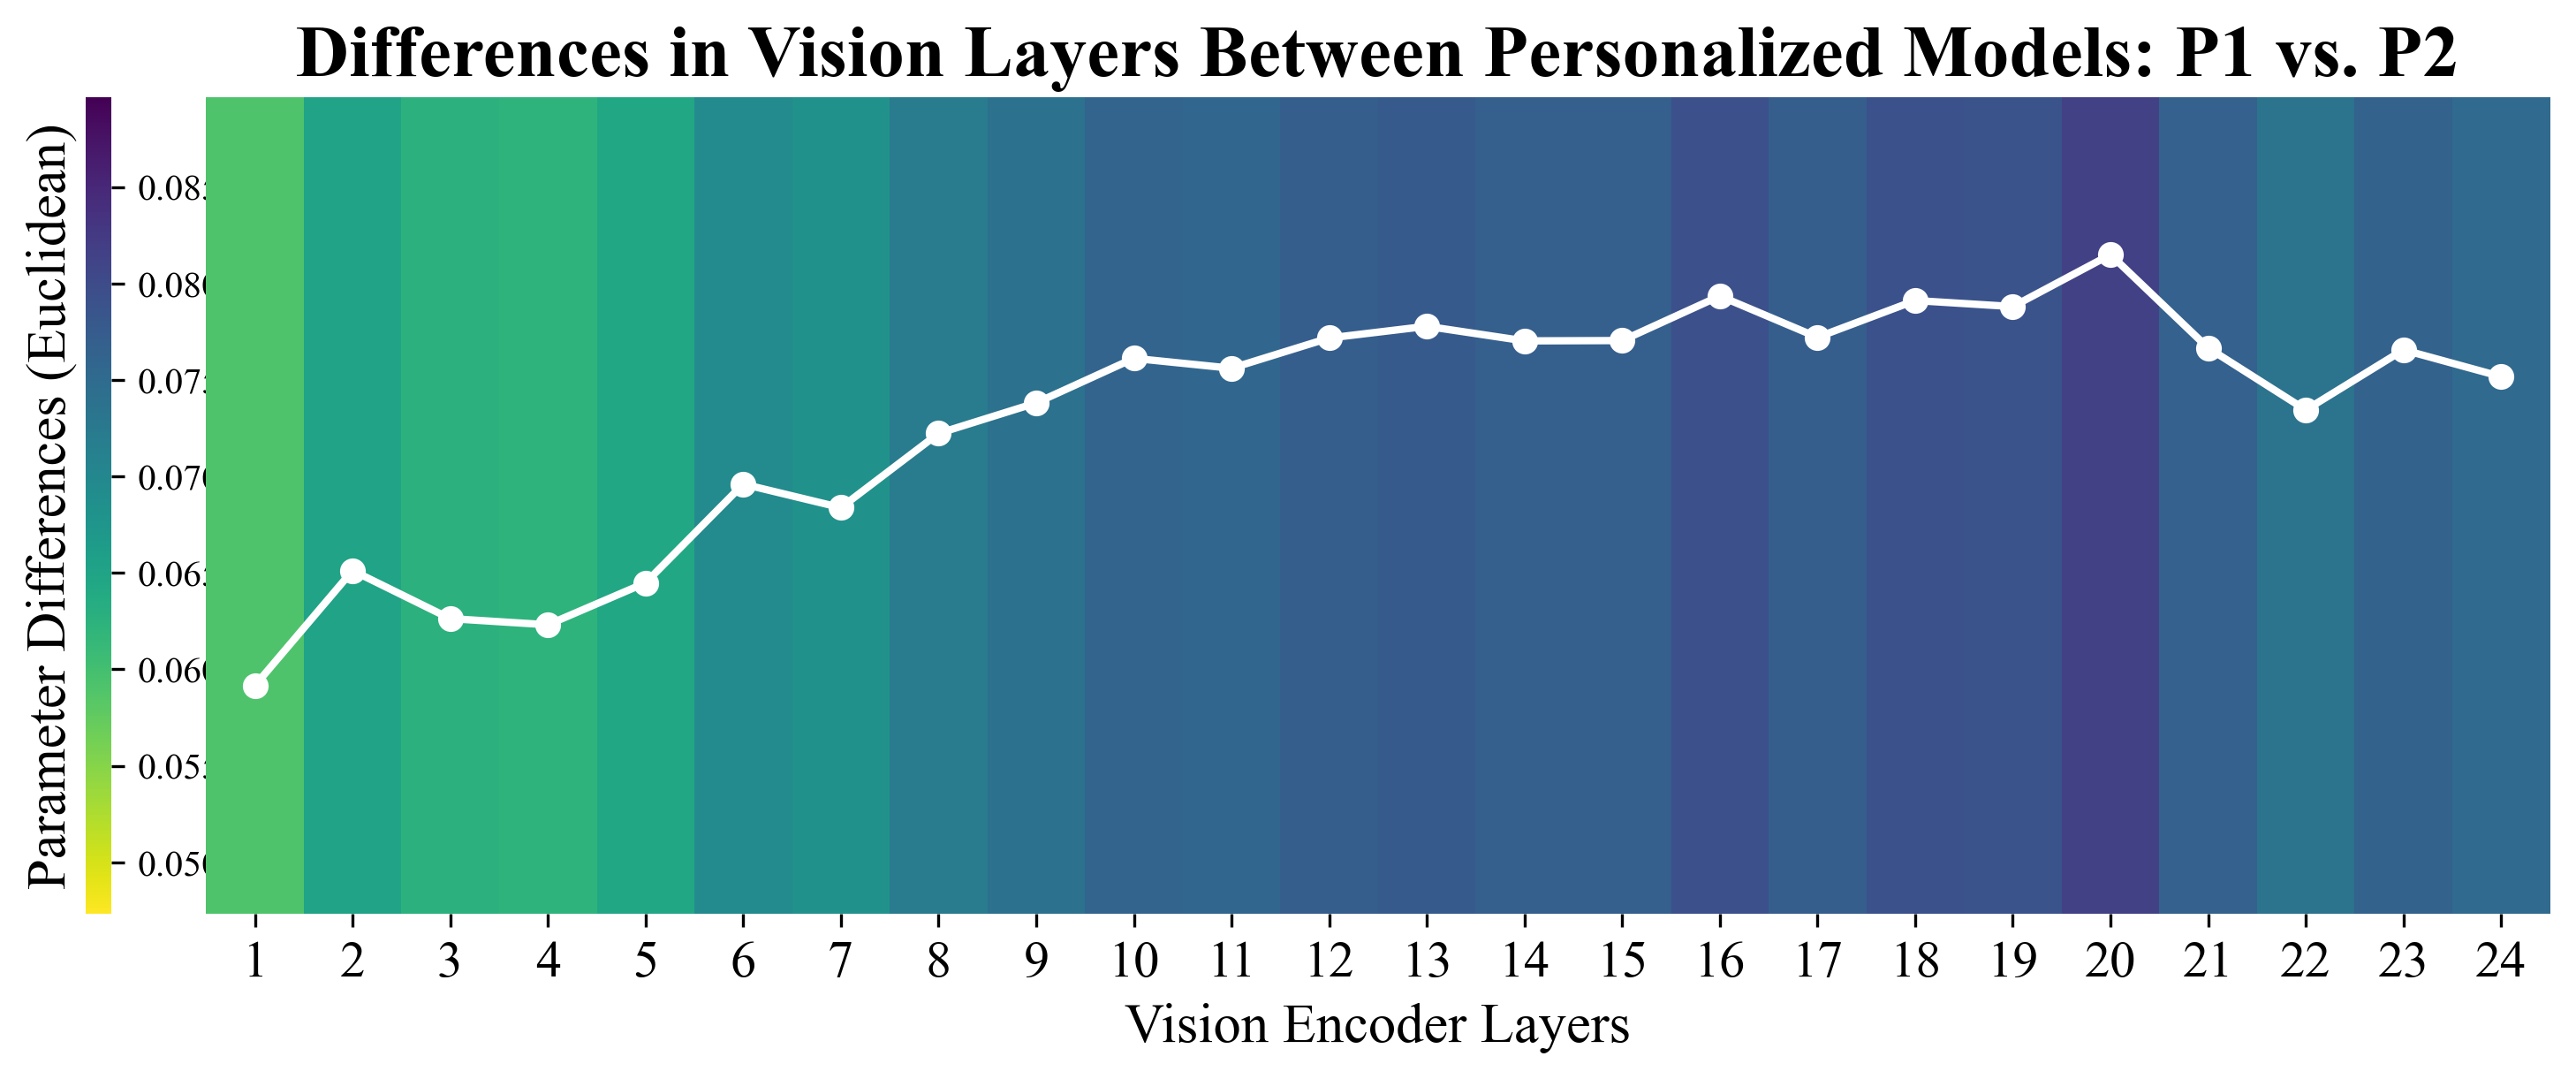

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.family'] = 'Times New Roman'

# Calculate Euclidean distances for each layer
layerwise_distances = []
for layer_1, layer_2 in zip(weights_model_1, weights_model_2):
    layer_dists = []
    for key in layer_1.keys():
        if key in layer_2:
            weights_1 = layer_1[key].cpu().numpy().flatten()
            weights_2 = layer_2[key].cpu().numpy().flatten()
            dist = np.linalg.norm(weights_1 - weights_2)  # Euclidean distance
            layer_dists.append(dist)
    layerwise_distances.append(np.mean(layer_dists))

# Prepare heatmap data
heatmap_data = np.array(layerwise_distances).reshape(1, -1)

# Plot the heatmap with overlayed line plot
plt.figure(figsize=(12, 4), dpi=300)

gs = gridspec.GridSpec(1, 2, width_ratios=[0.01, 0.9], wspace=0.08)
cbar_ax = plt.subplot(gs[0, 0])
main_ax = plt.subplot(gs[0, 1])

# set facecolor to none
main_ax.set_facecolor('none')
cbar_ax.set_frame_on(False)

vmin, vmax = 0.8*min(layerwise_distances), 1.1*max(layerwise_distances)
custom_cmap = LinearSegmentedColormap.from_list("custom_white_red", ["white", "orange"])
# Plot the heatmap
sns.heatmap(
    heatmap_data, 
    cmap="viridis_r", 
    cbar=True, 
    xticklabels=range(1, 25), 
    yticklabels=[], 
    annot=False,
    vmin=vmin, 
    vmax=vmax,
    cbar_ax=cbar_ax,
    ax=main_ax
)

# Move colorbar ticks to the left
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')

# Adjust the heatmap plot
main_ax.set_xlabel("Vision Encoder Layers", fontsize=15)
main_ax.set_ylabel("Parameter Differences (Euclidean)", fontsize=15, labelpad=35)
main_ax.set_title(f"Differences in Vision Layers Between Personalized Models: P{p_id+1} vs. P{p_id_2+1}", fontsize=20, fontweight="bold")
main_ax.tick_params(axis='x', labelsize=14)
main_ax.tick_params(axis='y', labelsize=14)

# Overlay line plot on the heatmap
x_values = np.arange(0.5, 24.5, 1)  # Shift x values to align with heatmap centers
y_values = layerwise_distances
main_ax.plot(x_values, y_values, color="w", marker="o", linewidth=2, label="Euclidean Distances")
main_ax.set_ylim(vmin, vmax)  # Adjust Y-axis scale to emphasize differences

plt.show()


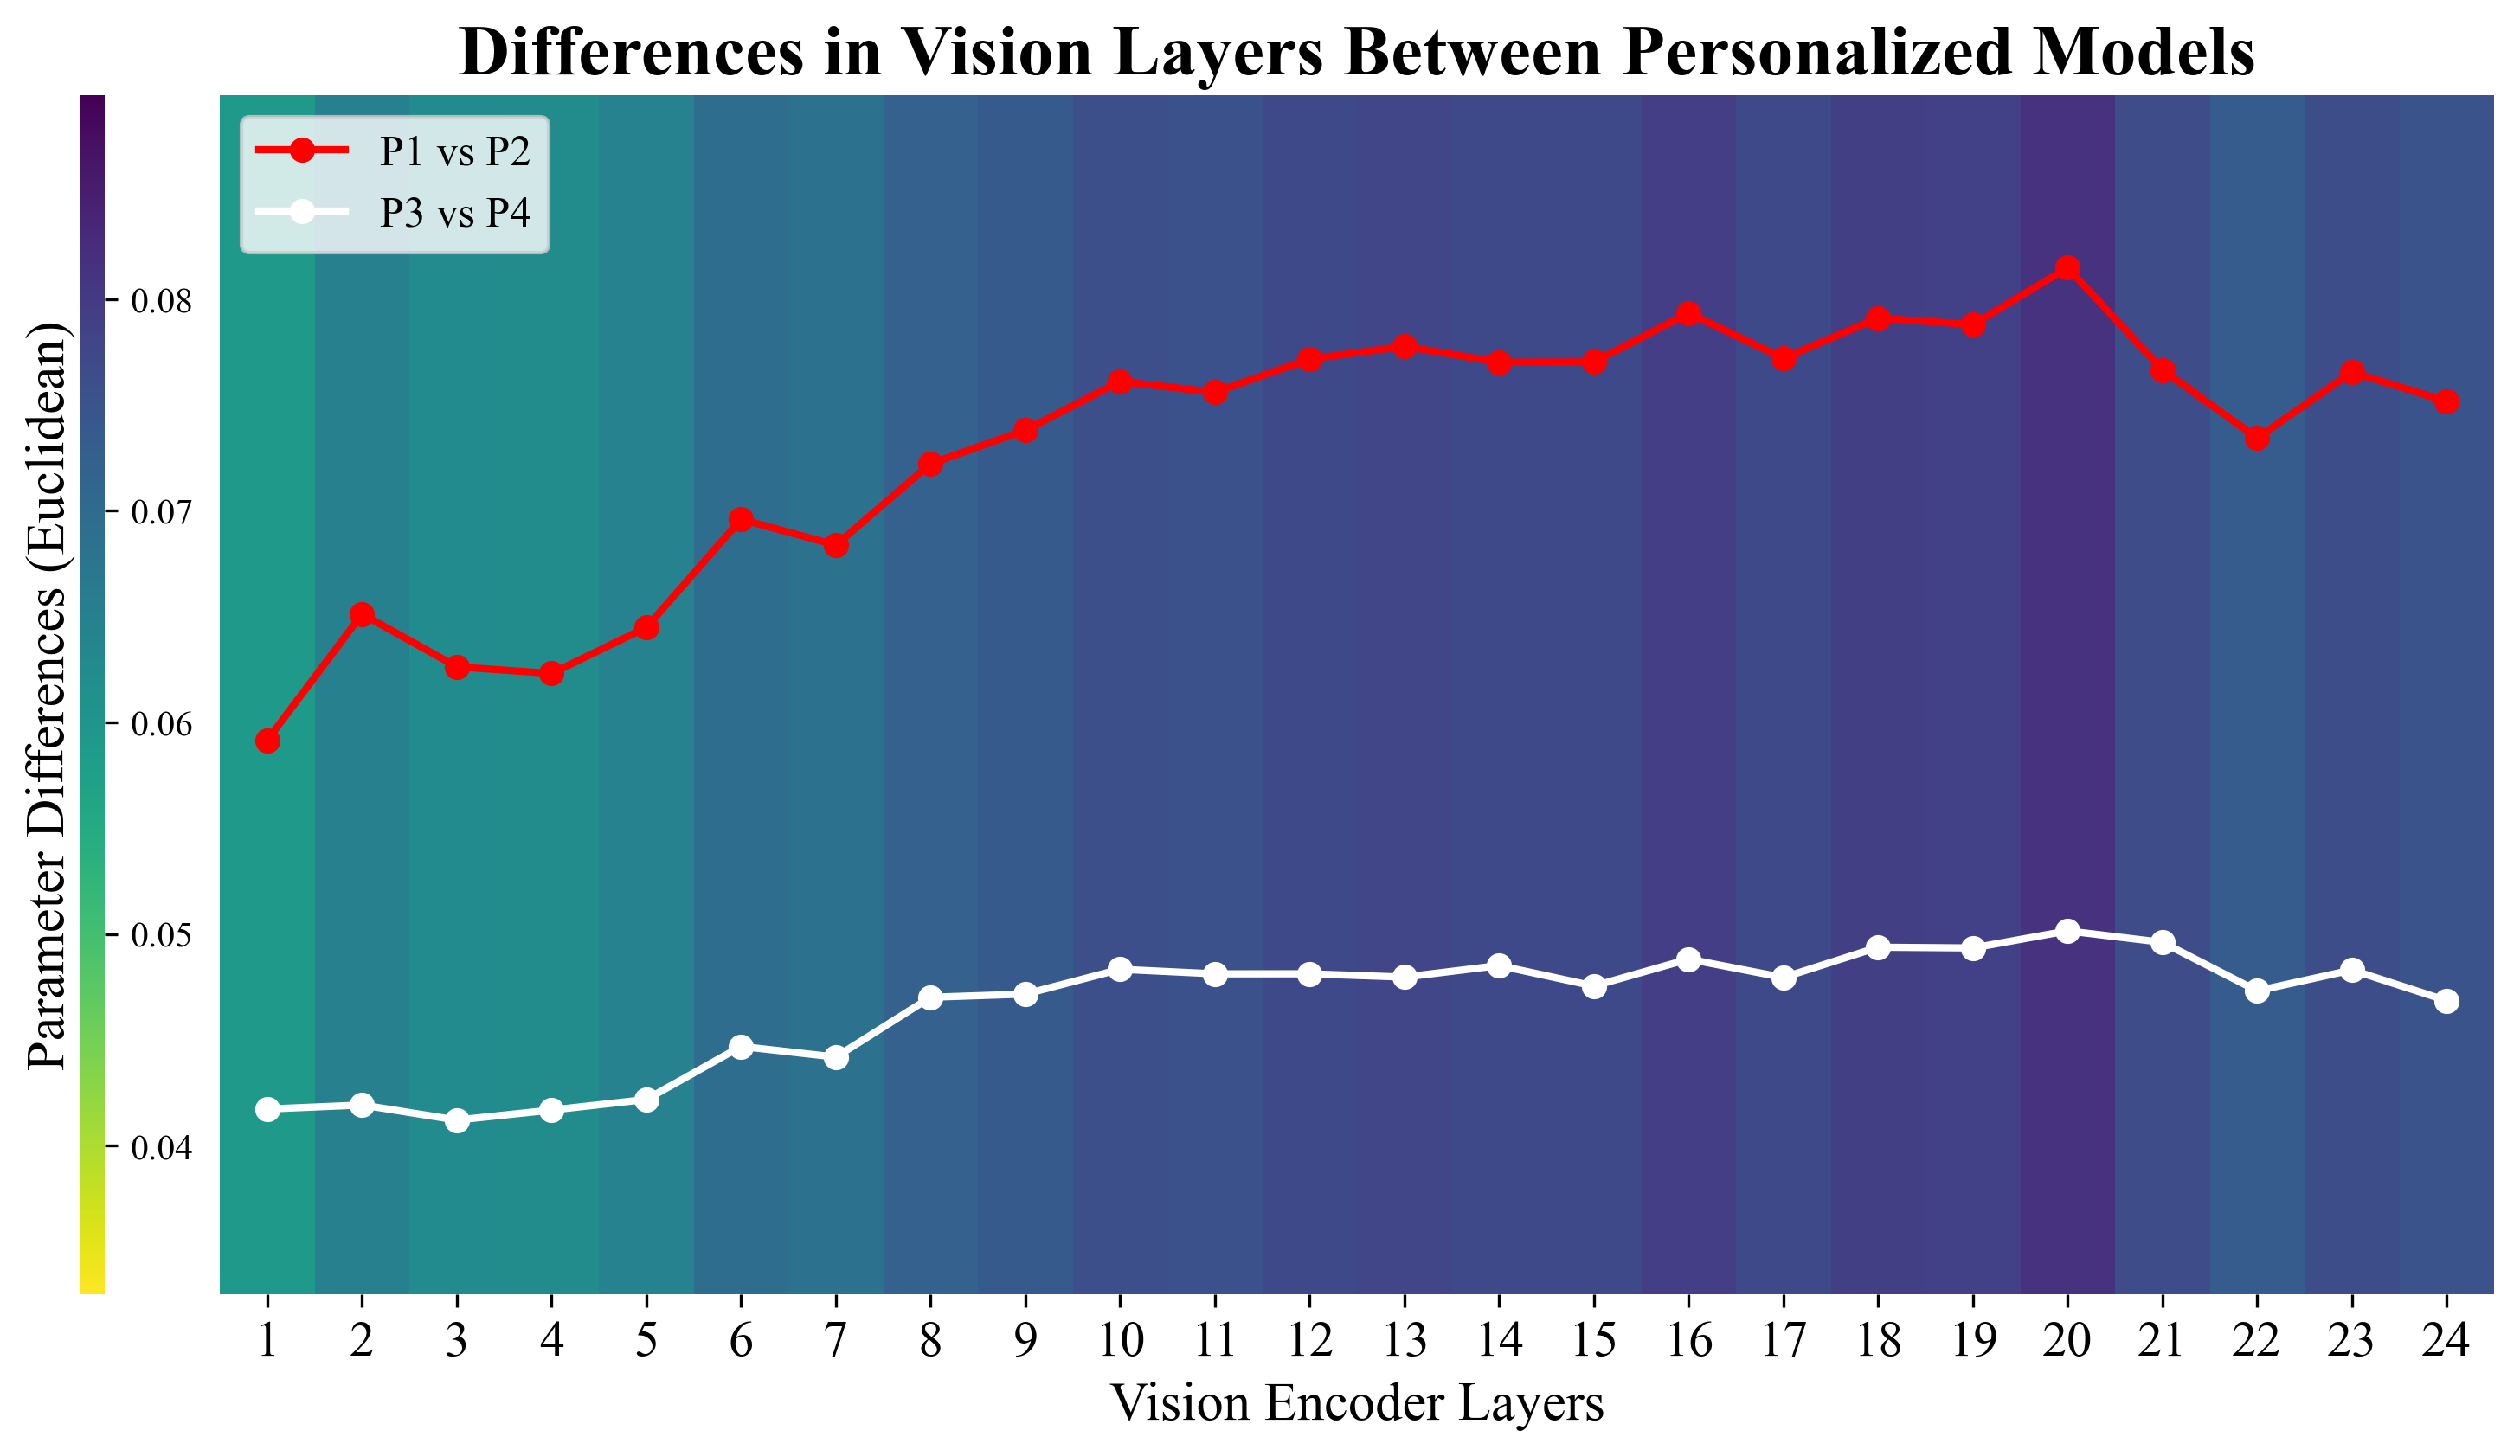

In [3]:
def plot_layerwise_distances(weights_model_1, p_id_1, weights_model_2, p_id_2, weights_model_3, p_id_3, weights_model_4, p_id_4, vmin=0.01, vmax=0.1):
    plt.rcParams['font.family'] = 'Times New Roman'

    def compute_layerwise_distances(model_1, model_2):
        distances = []
        for layer_1, layer_2 in zip(model_1, model_2):
            layer_dists = []
            for key in layer_1.keys():
                if key in layer_2:
                    weights_1 = layer_1[key].cpu().numpy().flatten()
                    weights_2 = layer_2[key].cpu().numpy().flatten()
                    dist = np.linalg.norm(weights_1 - weights_2)  # Euclidean distance
                    layer_dists.append(dist)
            distances.append(np.mean(layer_dists))
        return distances

    # Compute distances for both pairs
    distances_1_vs_2 = compute_layerwise_distances(weights_model_1, weights_model_2)
    distances_3_vs_4 = compute_layerwise_distances(weights_model_3, weights_model_4)

    # Prepare heatmap data
    heatmap_data = np.array([distances_1_vs_2, distances_3_vs_4])

    # Plot the heatmap with overlayed line plot
    plt.figure(figsize=(12, 6), dpi=300)

    gs = gridspec.GridSpec(1, 2, width_ratios=[0.01, 0.9], wspace=0.1)
    cbar_ax = plt.subplot(gs[0, 0])
    main_ax = plt.subplot(gs[0, 1])

    # Set facecolor to none
    main_ax.set_facecolor('none')
    cbar_ax.set_frame_on(False)

    vmin, vmax = 0.8*min(min(distances_1_vs_2), min(distances_3_vs_4)), 1.1*max(max(distances_1_vs_2), max(distances_3_vs_4))

    # Plot the heatmap
    sns.heatmap(
        heatmap_data, 
        cmap="viridis_r", 
        cbar=True, 
        xticklabels=range(1, 25), 
        yticklabels=[f"P{p_id_1+1} vs P{p_id_2+1}", f"P{p_id_1+3} vs P{p_id_2+3}"], 
        annot=False,
        vmin=vmin, 
        vmax=vmax,
        cbar_ax=cbar_ax,
        ax=main_ax
    )

    # Move colorbar ticks to the left
    cbar_ax.yaxis.set_ticks_position('right')
    cbar_ax.yaxis.set_label_position('right')

    # Adjust the heatmap plot
    main_ax.set_xlabel("Vision Encoder Layers", fontsize=15)
    main_ax.set_ylabel("Parameter Differences (Euclidean)", fontsize=15, labelpad=40)
    main_ax.set_title(
        f"Differences in Vision Layers Between Personalized Models",
        fontsize=20, fontweight="bold"
    )
    main_ax.tick_params(axis='x', labelsize=14)
    main_ax.tick_params(axis='y', labelsize=14)

    # Overlay line plot on the heatmap
    x_values = np.arange(0.5, 24.5, 1)  # Shift x values to align with heatmap centers
    main_ax.plot(x_values, distances_1_vs_2, color="r", marker="o", linewidth=2, label=f"P{p_id_1+1} vs P{p_id_2+1}")
    main_ax.plot(x_values, distances_3_vs_4, color="w", marker="o", linewidth=2, label=f"P{p_id_3+1} vs P{p_id_4+1}")

    # Add legend
    main_ax.legend(loc="upper left", fontsize=12)

    # Adjust Y-axis scale to emphasize differences
    main_ax.set_ylim(vmin, vmax)

    plt.show()


plot_layerwise_distances(weights_model_1, p_id, weights_model_2, p_id_2, weights_model_3, p_id_3, weights_model_4, p_id_4, vmin=vmin, vmax=vmax)

c:\ProgramData\miniconda3\envs\cliphba\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


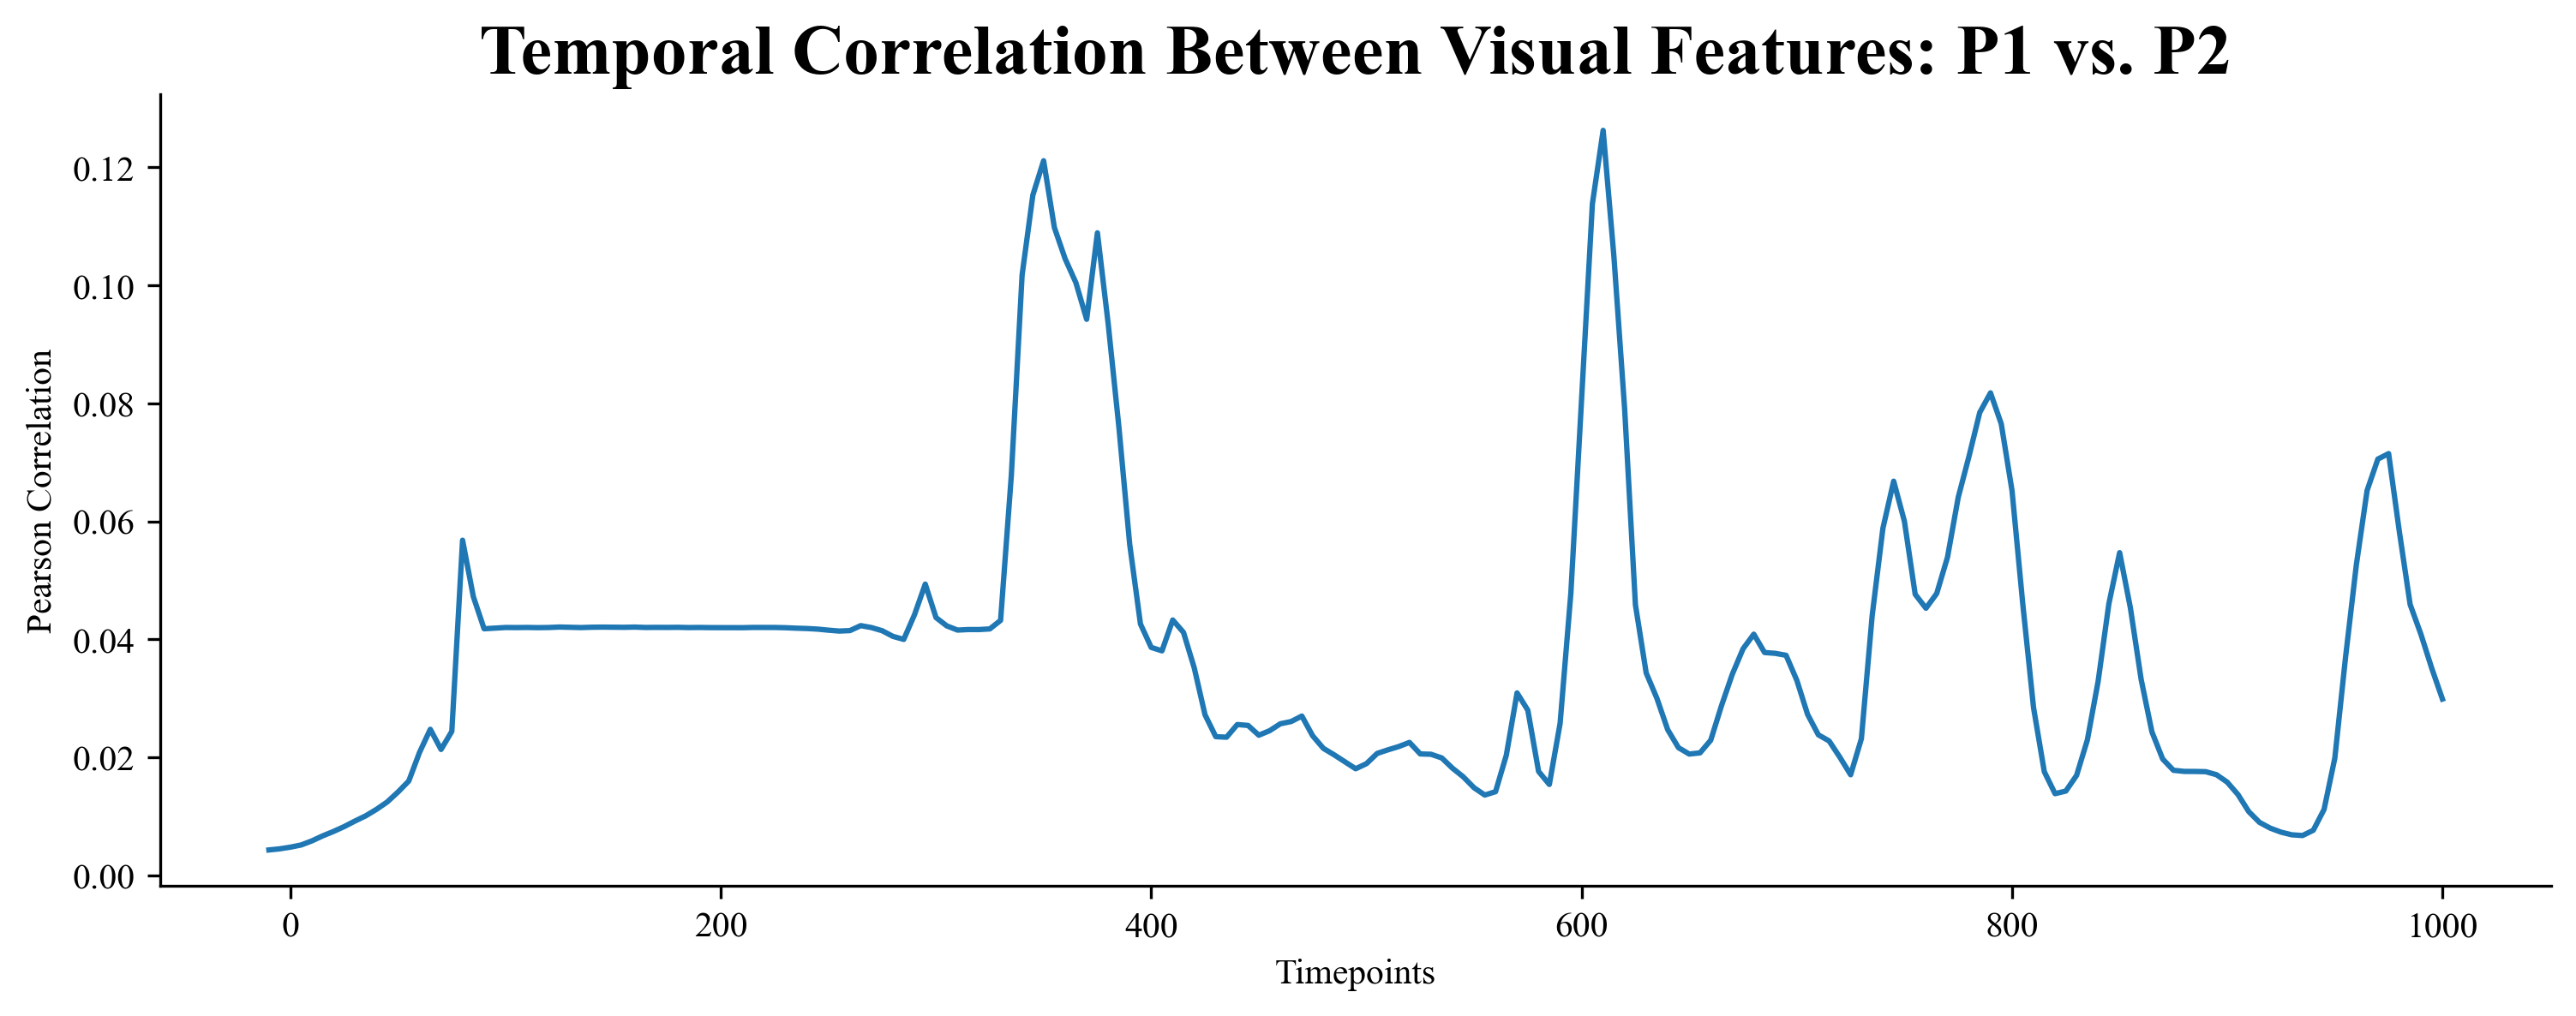

In [4]:
feature_path = '../output/cliphba_individual_cichy_official_v2/cichy/overall_visual_feature.npy'
feature = np.load(feature_path)

feature1 = feature[p_id]
feature2 = feature[p_id_2]

# flatten the last 2 dimensions for each feature
feature1 = feature1.reshape(feature1.shape[0], -1)
feature2 = feature2.reshape(feature2.shape[0], -1)

# calculate pearson correlation for each timepoint (feature shape is (timepoints, features))
model_corrs = []

for i in range(feature1.shape[0]):
    corr, _ = pearsonr(feature1[i], feature2[i])
    model_corrs.append(1 - corr)

timepoints = list(range(-100, 1001, 5))

def timepoint_to_index(timepoint, step=1):
    return int((timepoint + 100) // step)

# starting_index = timepoint_to_index(-100, 5)

# model_corrs = model_corrs[starting_index:]
# timepoints = timepoints[starting_index:]

fig, ax = plt.subplots(figsize=(12, 4), dpi=300)  # Set resolution
fig.patch.set_facecolor('none')  # Remove figure background
ax.set_facecolor('none')  # Remove axes background
plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman


plt.plot(timepoints, model_corrs)
plt.xlabel('Timepoints')
plt.ylabel('Pearson Correlation')
plt.title(f"Temporal Correlation Between Visual Features: P{p_id+1} vs. P{p_id_2+1}", fontsize=20, fontweight="bold")

# Remove top and right frame
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

20
[0.004818883725113743, 0.005192026869823341, 0.005883064617953848, 0.006730981735530439, 0.007474151365914228, 0.008303084861670862, 0.009241894668442163, 0.010125235181319026, 0.011222443410184968, 0.012477445427024225, 0.014160190906945203, 0.016016750406358526, 0.020872725510625023, 0.02478343258769955, 0.02136365391662809, 0.024425393914196736, 0.05680395832014806, 0.04724953386796238, 0.04180762092649071, 0.04192096781114407, 0.042022095288730466, 0.04200925869989258, 0.04202811791574157, 0.04199733254364757, 0.04201997011018277, 0.04209861656048486, 0.04204885879410514, 0.04200931884508585, 0.04206559670061738, 0.042086828432114864, 0.04207239441136146, 0.042051953154073285, 0.04209061613793674, 0.042026786557855966, 0.04204110232236258, 0.042033366604277145, 0.04205179706735218, 0.04201001820828976, 0.04202815237232482, 0.04200226258617601, 0.04200041097196383, 0.042006905910210834, 0.0419911619403186, 0.0420309792880027, 0.04203239419984339, 0.042025422673253265, 0.041986374

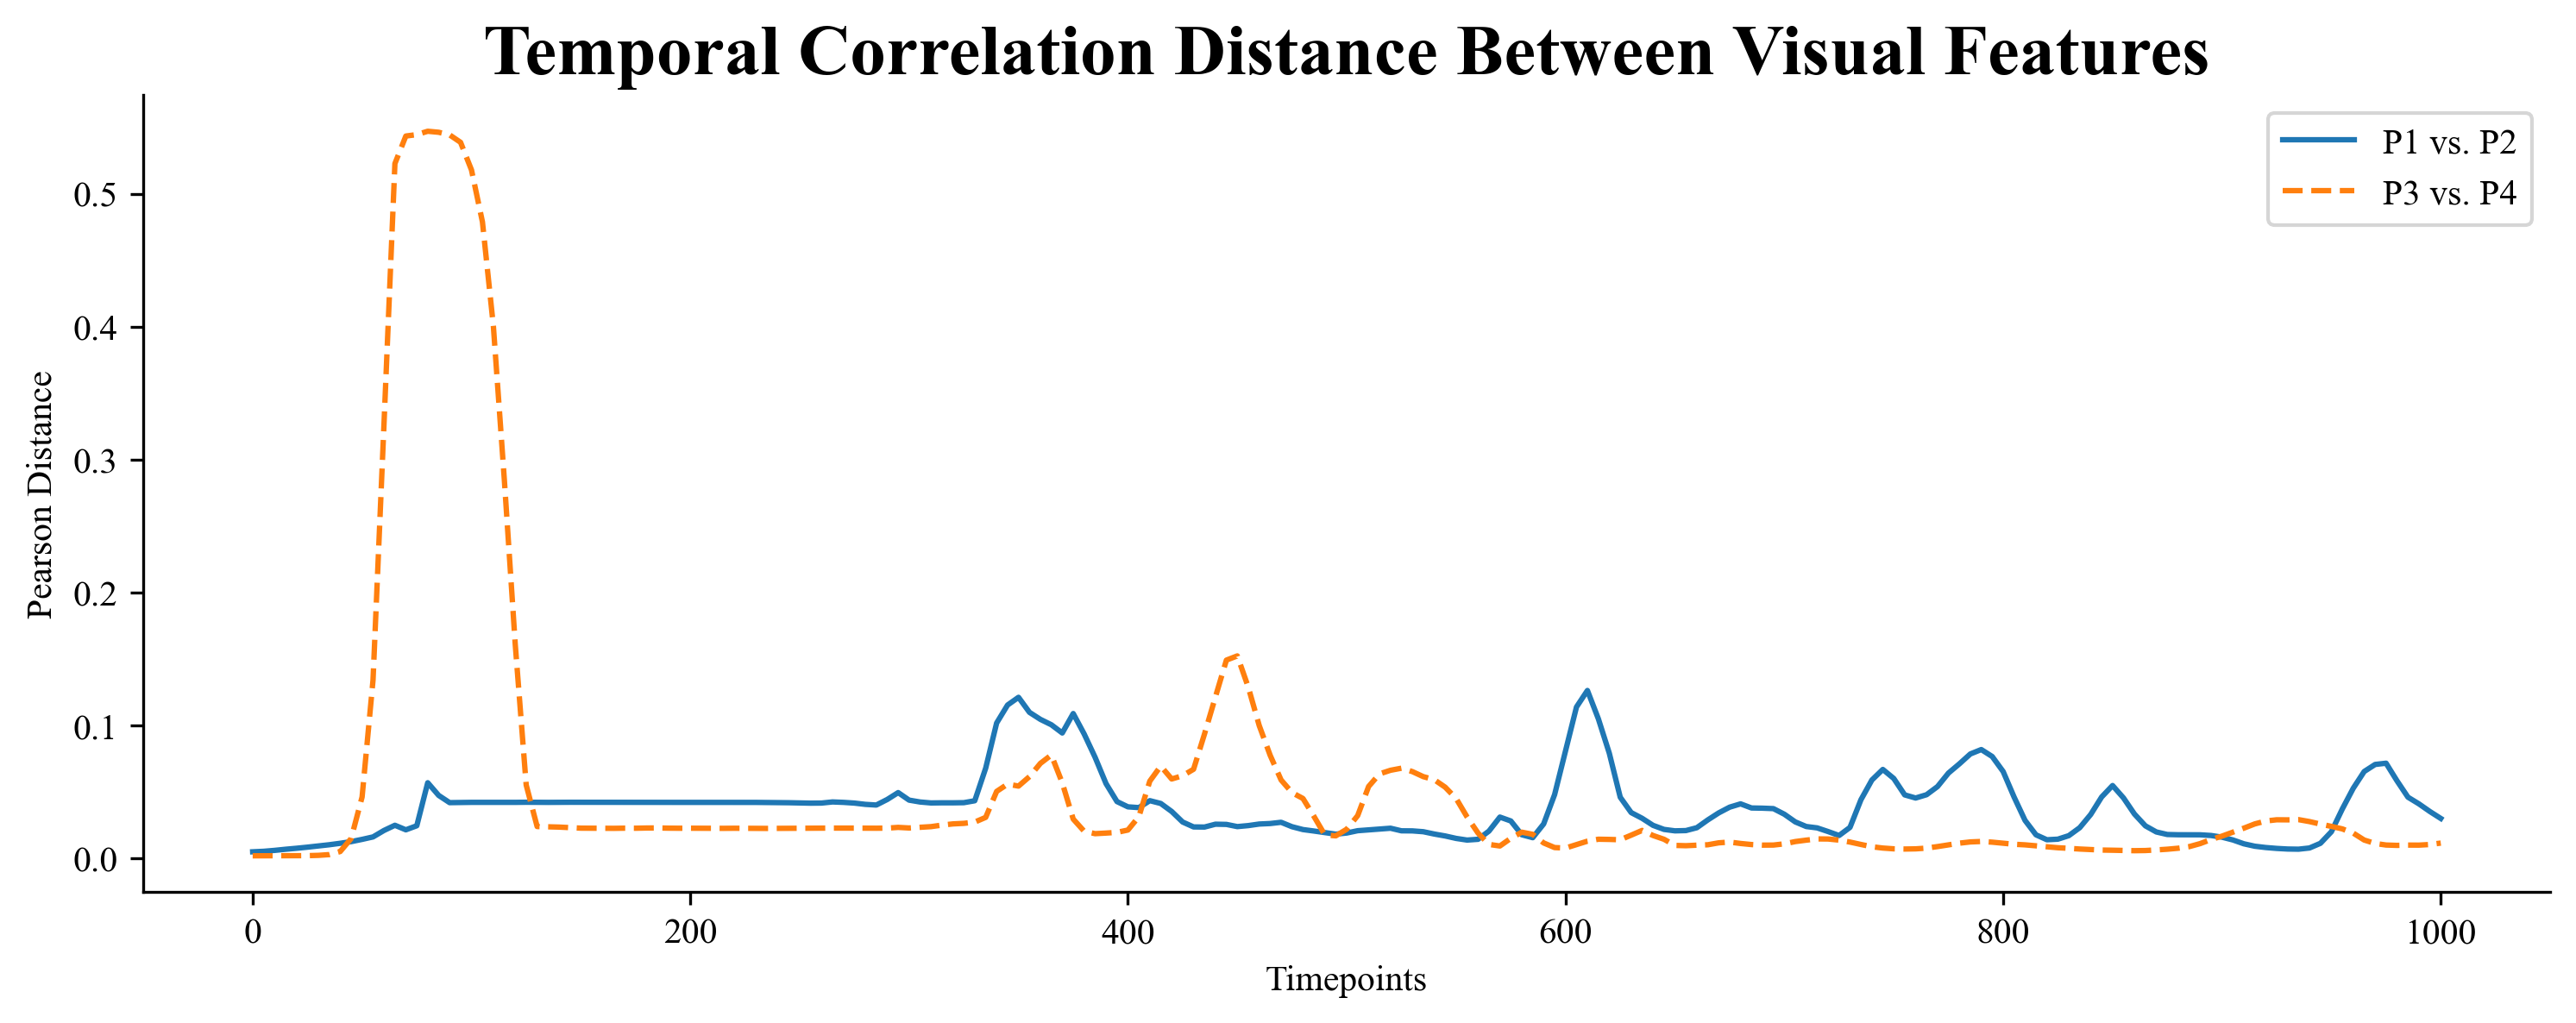

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_feature_correlations(weights_model_1, p_id, weights_model_2, p_id_2, 
                              weights_model_3, p_id_3, weights_model_4, p_id_4):
    def process_features(weights_model, p_id):
        feature = np.load(weights_model)
        feature = feature[p_id]
        return feature.reshape(feature.shape[0], -1)

    def calculate_correlations(feature1, feature2):
        corrs = []
        for i in range(feature1.shape[0]):
            corr, _ = pearsonr(feature1[i], feature2[i])
            corrs.append(1 - corr)
        return corrs
    def timepoint_to_index(timepoint, step=1):
        return int((timepoint + 100) // step)


    # Process features
    feature1 = process_features(weights_model_1, p_id)
    feature2 = process_features(weights_model_2, p_id_2)
    feature3 = process_features(weights_model_3, p_id_3)
    feature4 = process_features(weights_model_4, p_id_4)

    # Calculate correlations
    model_corrs_1 = calculate_correlations(feature1, feature2)
    model_corrs_2 = calculate_correlations(feature3, feature4)

    # Define timepoints
    timepoints = list(range(-100, 1001, 5))
    starting_index = timepoint_to_index(0, 5)

    print(starting_index)

    model_corrs_1 = model_corrs_1[starting_index:]
    model_corrs_2 = model_corrs_2[starting_index:]
    timepoints = timepoints[starting_index:]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4), dpi=300)
    fig.patch.set_facecolor('none')
    ax.set_facecolor('none')
    plt.rcParams['font.family'] = 'Times New Roman'

    print(model_corrs_1)

    plt.plot(timepoints, model_corrs_1, label=f"P{p_id+1} vs. P{p_id_2+1}")
    plt.plot(timepoints, model_corrs_2, label=f"P{p_id_3+1} vs. P{p_id_4+1}", linestyle="--")

    plt.xlabel('Timepoints')
    plt.ylabel('Pearson Distance')
    plt.title("Temporal Correlation Distance Between Visual Features", fontsize=20, fontweight="bold")

    # Remove top and right frame
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add legend
    plt.legend()

    plt.show()

plot_feature_correlations(feature_path, p_id, feature_path, p_id_2, feature_path, p_id_3, feature_path, p_id_4)

(118, 66) (118, 66)


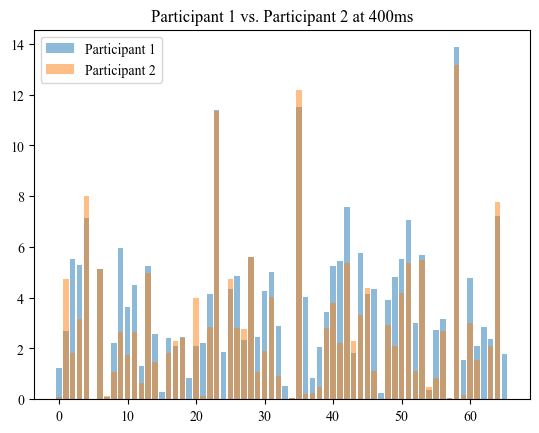

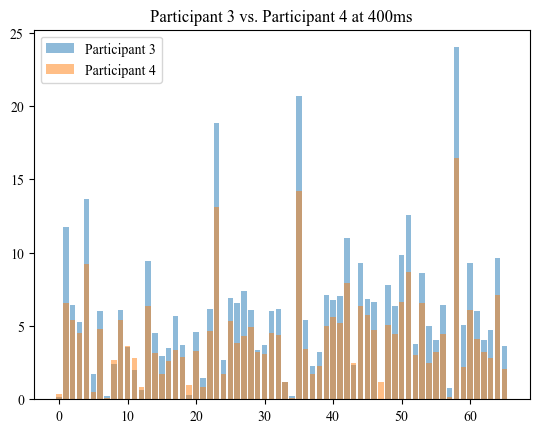

In [6]:
path = f'../output/cliphba_individual_cichy_official_v2/cichy/overall_embs.npy'
embs = np.load(path)
# turn everything negative to 0
# embs[embs < 0] = 0


ms = 400
ms_index = timepoint_to_index(ms, 5)

image_index = 0


embs_1 = embs[p_id][ms_index]
embs_2 = embs[p_id_2][ms_index]
embs_3 = embs[p_id_3][ms_index]
embs_4 = embs[p_id_4][ms_index]

print(embs_1.shape, embs_2.shape)

p1_img = embs_1[image_index]
p2_img = embs_2[image_index]
p3_img = embs_3[image_index]
p4_img = embs_4[image_index]



plt.bar(range(66), p1_img, alpha=0.5, label=f'Participant {p_id+1}')
plt.bar(range(66), p2_img, alpha=0.5, label=f'Participant {p_id_2+1}')
plt.title(f"Participant {p_id+1} vs. Participant {p_id_2+1} at {ms}ms")
plt.legend()
plt.show()



plt.bar(range(66), p3_img, alpha=0.5, label=f'Participant {p_id_3+1}')
plt.bar(range(66), p4_img, alpha=0.5, label=f'Participant {p_id_4+1}')
plt.title(f"Participant {p_id_3+1} vs. Participant {p_id_4+1} at {ms}ms")
plt.legend()
plt.show()




160
./Data/Cichy/stimuli/stimulus001.png


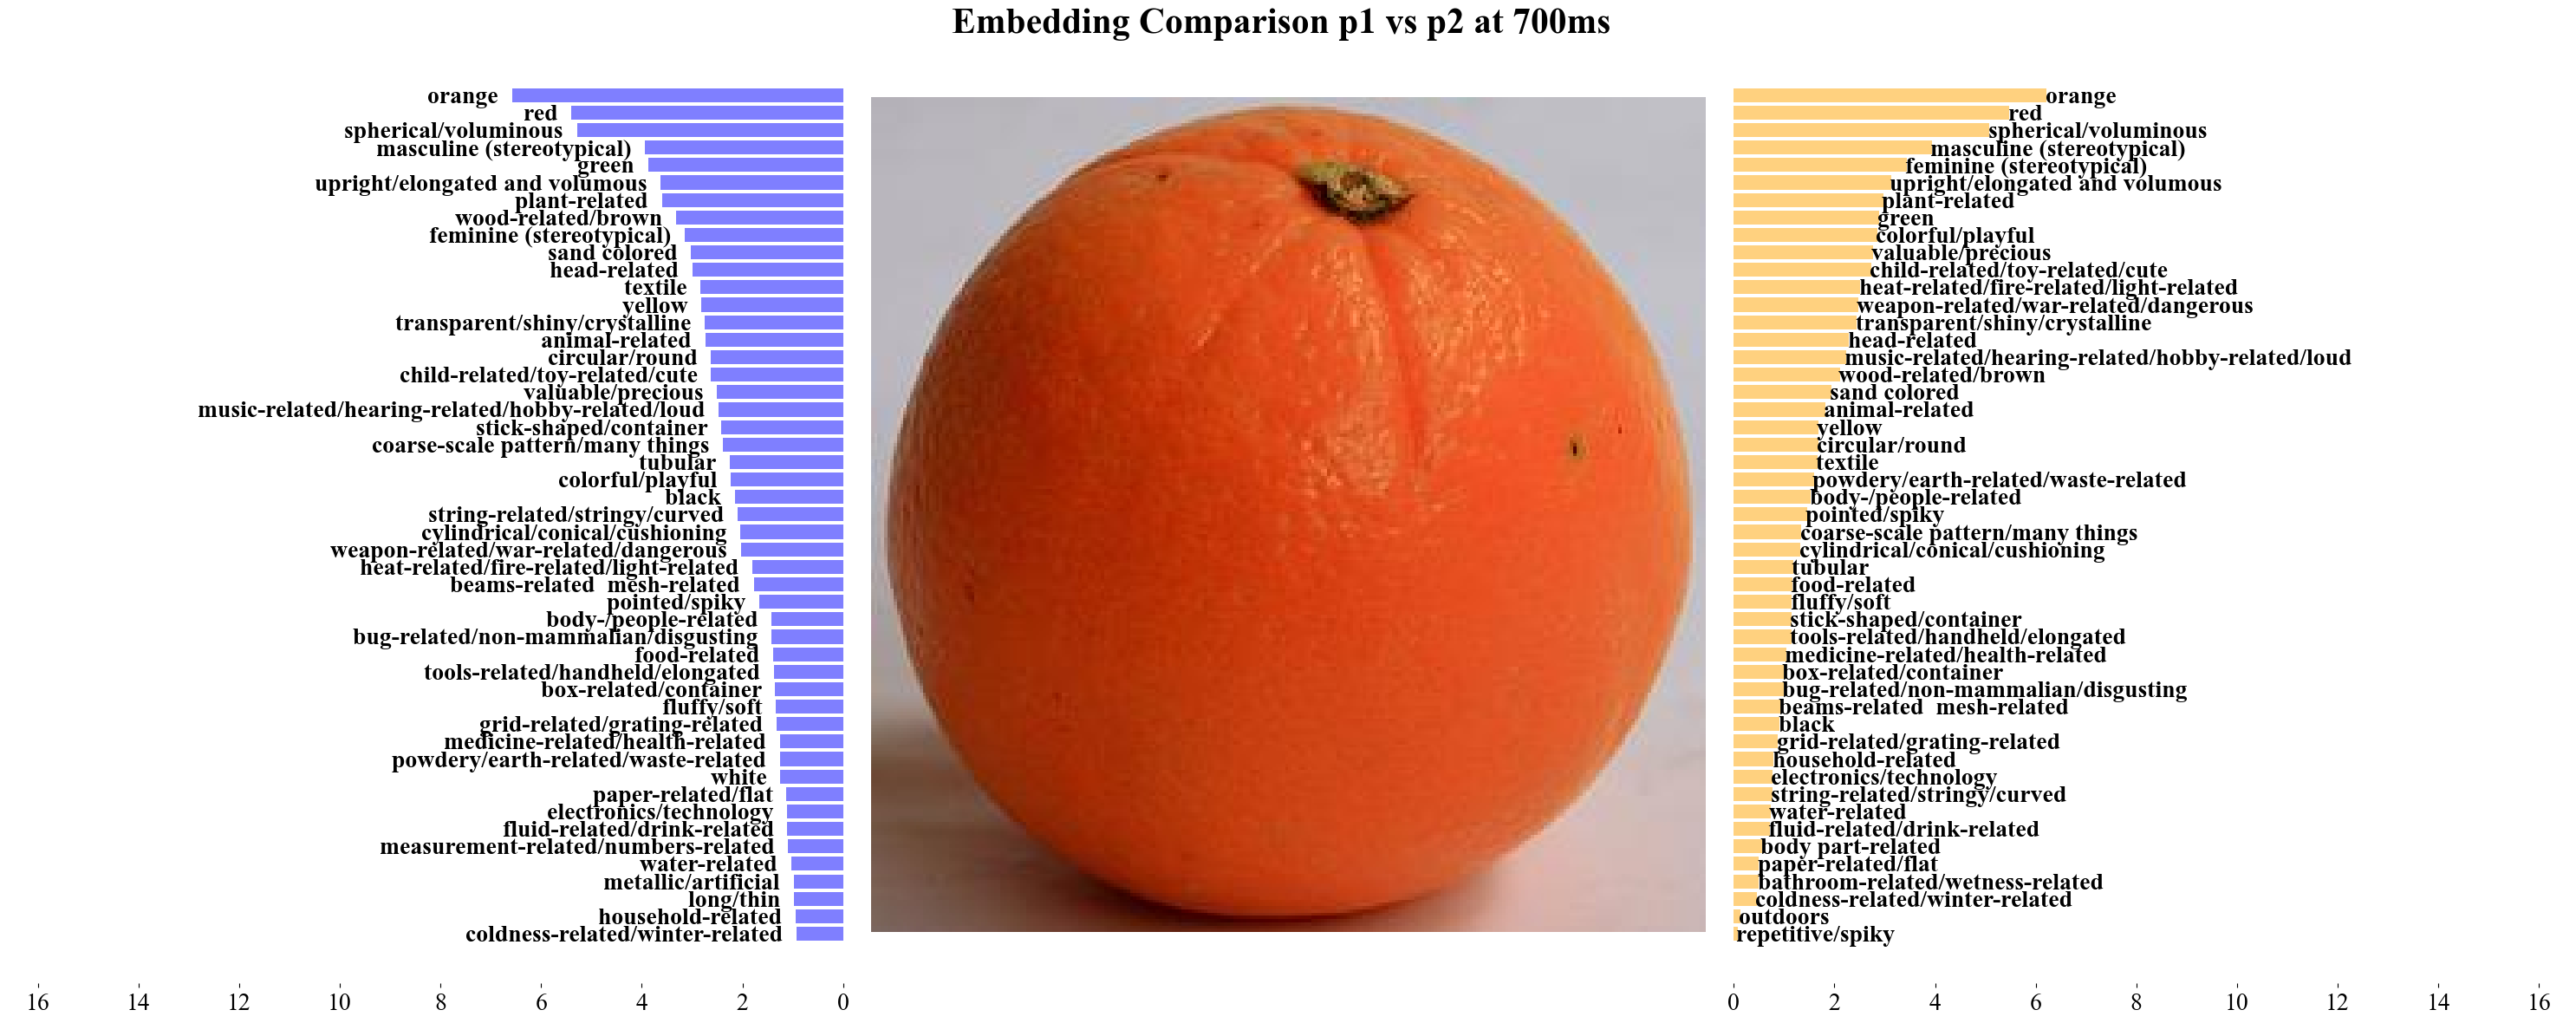

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

object = 'stimulus001'

emb_path = f'../output/cliphba_individual_cichy_official_v2/cichy/overall_embs.npy'
overall_embs = np.load(emb_path)
# turn everything negative to 0
# overall_embs[overall_embs < 0] = 0

ms = 700
ms_index = timepoint_to_index(ms, 5)
print(ms_index)

emb_1 = overall_embs[p_id][ms_index]
emb_2 = overall_embs[p_id_2][ms_index]

img_dir = "./Data/Cichy/stimuli/"

image_names = os.listdir(img_dir)

label_path = './Data/labels66.txt'
with open(label_path) as f:
    labels = f.readlines()

# get rid of any "\n" characters in labels
labels = [label.strip() for label in labels]

# create df_emb_! and df_emb_2 with image names in the first column and the embedding in the rest, dimensions columns using labels

df_emb_1 = pd.DataFrame(emb_1, columns=labels)
df_emb_1['image'] = image_names

# move image column to the front
cols = df_emb_1.columns.tolist()
cols = cols[-1:] + cols[:-1]
df_emb_1 = df_emb_1[cols]

df_emb_2 = pd.DataFrame(emb_2, columns=labels)
df_emb_2['image'] = image_names
df_emb_2 = df_emb_2[cols]

# Filter the specific object
df_emb_1 = df_emb_1[df_emb_1['image'].str.contains(f'{object}')]
df_emb_2 = df_emb_2[df_emb_2['image'].str.contains(f'{object}')]

# Load image
image_path = img_dir + df_emb_1['image'].values[0]
print(image_path)
img = mpimg.imread(image_path)


# Sort values for bar plots
emb_1_histogram = df_emb_1.iloc[0, 1:].sort_values(ascending=False).head(49).sort_values()
emb_2_histogram = df_emb_2.iloc[0, 1:].sort_values(ascending=False).head(49).sort_values()

# Format labels
emb_1_histogram.index = emb_1_histogram.index.str.replace(" / ", "/", regex=False)
emb_2_histogram.index = emb_2_histogram.index.str.replace(" / ", "/", regex=False)

# Plot configuration
import matplotlib.font_manager as font_manager
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(1, 3, figsize=(30, 12), gridspec_kw={'width_ratios': [1, 1, 1]})

# Left-side mirrored bar plot (emb_2)
ax[0].barh(range(len(emb_1_histogram)), emb_1_histogram.values, color='blue', alpha=0.5)
ax[0].invert_xaxis()  # Flip the x-axis to go from 100 to 0
axis_scale = axis_scale = max(emb_1_histogram.values.max(), emb_2_histogram.values.max()) + 10
ax[0].set_xlim(axis_scale, 0)
ax[0].set_yticks([])
ax[0].tick_params(axis='x', labelsize=20)
for i, (value, label) in enumerate(zip(emb_1_histogram.values, emb_1_histogram.index)):
    ax[0].text(value + 0.15, i - 0.1, f'{label} ', va='center', ha='right', fontsize=20, fontweight='bold')
for spine in ax[0].spines.values():
    spine.set_visible(False)
ax[0].set_facecolor('none')

# Center image
ax[1].imshow(img)
ax[1].axis('off')
ax[1].set_facecolor('none')

# Right-side bar plot (emb_1)
ax[2].barh(range(len(emb_2_histogram)), emb_2_histogram.values, color='orange', alpha=0.5)
ax[2].set_xlim(0, axis_scale)
ax[2].set_yticks([])
ax[2].tick_params(axis='x', labelsize=20)
for i, (value, label) in enumerate(zip(emb_2_histogram.values, emb_2_histogram.index)):
    ax[2].text(value - 0.15, i - 0.1, f' {label}', va='center', ha='left', fontsize=20, fontweight='bold')
for spine in ax[2].spines.values():
    spine.set_visible(False)
ax[2].set_facecolor('none')

# Set figure transparency
fig.patch.set_alpha(0)

fig.suptitle(f'Embedding Comparison p{p_id+1} vs p{p_id_2+1} at {ms}ms', fontsize=30, fontweight='bold')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.show()
# plt.savefig(f'../figures/{object}_emb_2_vs_emb_1.svg', format='svg', bbox_inches='tight', transparent=True)


0.3829579333391149
(15, 221, 118, 66)


Computing Participant Correlation - p1:  35%|███▍      | 77/221 [00:00<00:00, 703.75it/s]

Computing Participant Correlation - p15: 100%|██████████| 221/221 [00:00<00:00, 786.15it/s]


(15, 221)


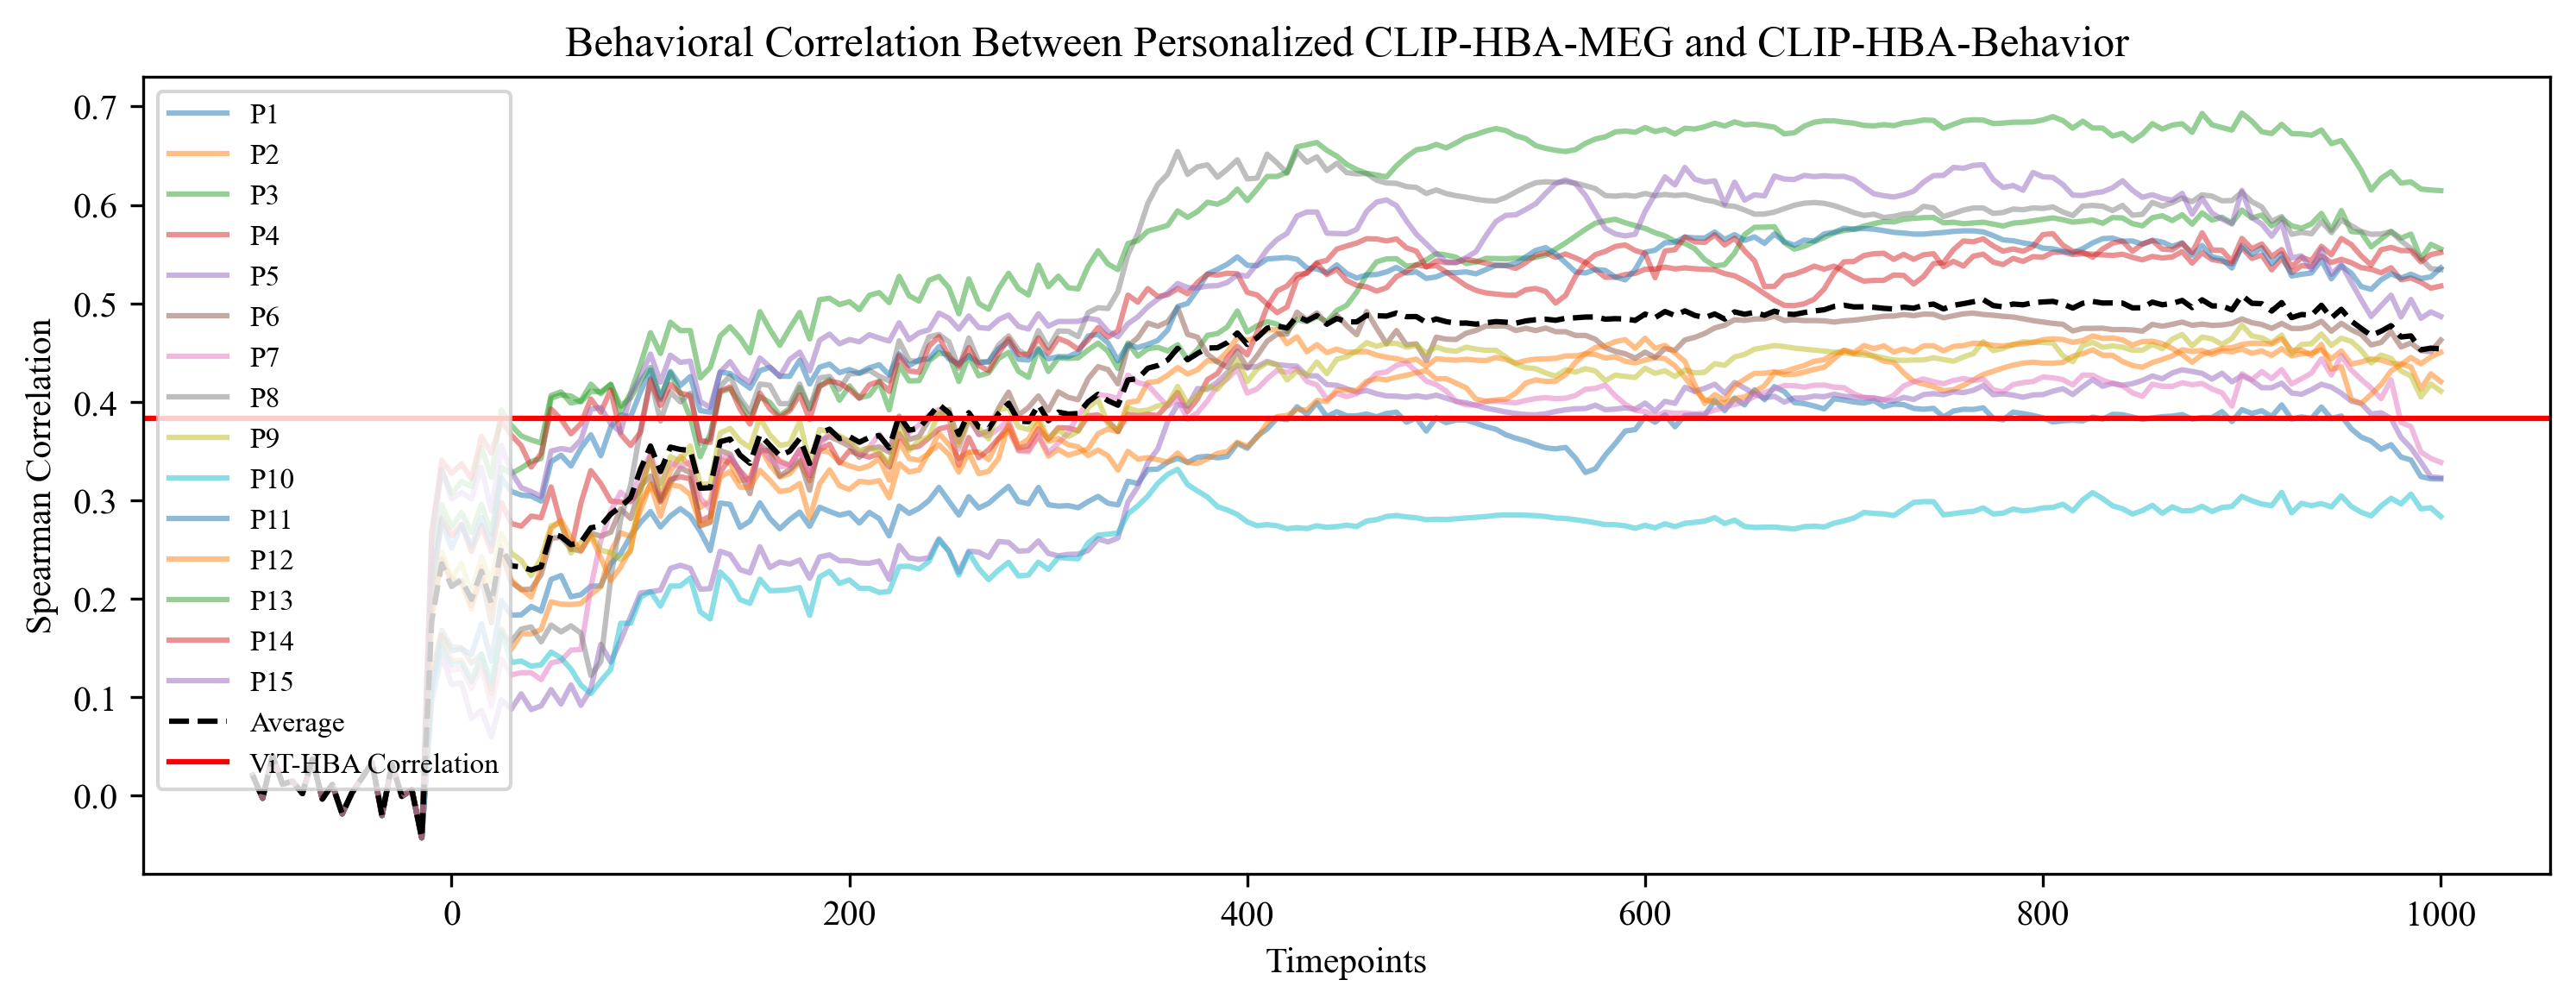

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

hba_emb_path = '../output/cliphba_66d_official/cichy/emb/static_embedding.csv'
hba_emb = pd.read_csv(hba_emb_path, index_col=0).values

vit_emb_path = "../output/clipvit_66d_baseline/cichy/emb/static_embedding.csv"
vit_emb = pd.read_csv(vit_emb_path, index_col=0).values

# build hba_rdm using cosine similarity

hba_rdm = 1 - cosine_similarity(hba_emb)
vit_rdm = 1 - cosine_similarity(vit_emb)

vit_hba_corr = spearmanr(vit_rdm[np.triu_indices_from(vit_rdm, k=1)], hba_rdm[np.triu_indices_from(hba_rdm, k=1)], nan_policy='omit')[0]

print(vit_hba_corr)

def compure_p_rdms(embs):
    rdms = []
    for timepoint in range(embs.shape[0]):
        emb = embs[timepoint]
        rdm = 1 - cosine_similarity(emb)
        rdms.append(rdm)
    return np.array(rdms)

print(overall_embs.shape)
rdm1 = compure_p_rdms(embs[p_id])
rdm2 = compure_p_rdms(embs[p_id_2])



def calculate_model_correlation(static_rdm, overall_embs, model_desc = "CLIP-HBA"):
    overall_corr = []
    for p in range(overall_embs.shape[0]):
        p_emb = overall_embs[p]
        p_rdms = compure_p_rdms(p_emb)

        p_correlation = []

        indices = np.triu_indices_from(static_rdm, k=1)
        static_rdm_flat = static_rdm[indices]
        for time_point in tqdm(range(p_rdms.shape[0]), desc=f"Computing Participant Correlation - p{p+1}"):
            p_rdms_flat = p_rdms[time_point][indices]
            corr, _ = spearmanr(static_rdm_flat, p_rdms_flat, nan_policy='omit')
            p_correlation.append(corr)
        overall_corr.append(p_correlation)
    return np.array(overall_corr)


corrs = calculate_model_correlation(hba_rdm, overall_embs)
print(corrs.shape)
avg_corrs = np.mean(corrs, axis=0)

timepoints = list(range(-100, 1001, 5))
# plot the correlation
plt.figure(figsize=(12, 4), dpi=300)
for p in range(corrs.shape[0]):
    plt.plot(timepoints, corrs[p], label=f"P{p+1}", alpha=0.5)
plt.plot(timepoints, avg_corrs, label="Average", color='black', linestyle='--')

# plot the line of vit_hba_corr
plt.axhline(y=vit_hba_corr, color='r', linestyle='-', label="ViT-HBA Correlation")

plt.title(f"Behavioral Correlation Between Personalized CLIP-HBA-MEG and CLIP-HBA-Behavior")
plt.xlabel("Timepoints")
plt.ylabel("Spearman Correlation")
plt.legend(fontsize=8)
plt.show()

